# MLP tutorial notebook: Breast Cancer Wisconsin classification

We will train a small MLP on the Breast Cancer Wisconsin (Diagnostic) dataset, loaded directly from
`sklearn.datasets`, to classify tumors as malignant or benign from $D_{input}=30$ numeric features
(radius, texture, perimeter, area, smoothness, ... each measured as mean / standard-error / "worst"
over cell nuclei in a digitized image).

The notebook is written so the same code can be reused for other 1D tabular classification datasets —
just swap out the data-loading cell.

## Setup

In [1]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Step 0: Load Breast Cancer Wisconsin

`sklearn.datasets.load_breast_cancer()` returns the full $N=569$ sample dataset directly as arrays, so
no download/parsing is needed. We'll build our **own** train/val/test split rather
than relying on a predefined one.

In [2]:
data = load_breast_cancer()

X = data.data.astype(np.float32)     # [N, 30] tabular features
y = data.target.astype(np.float32)   # 0 = malignant, 1 = benign

print(f"X shape: {X.shape}  (N={X.shape[0]} samples, D_input={X.shape[1]})")
print(f"class balance: {int((y==0).sum())} malignant (0) / {int((y==1).sum())} benign (1)")
print(f"first 5 feature names: {list(data.feature_names[:5])}")

X shape: (569, 30)  (N=569 samples, D_input=30)
class balance: 212 malignant (0) / 357 benign (1)
first 5 feature names: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]


## Ingredient 1: Standard DataLoader / split block

Notations for our dataset:
- $N = 569$ samples, $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^N$
- $x_i \in \mathbb{R}^{D_{input}}$ with $D_{input} = 30$ (tabular)
- $y_i \in \mathbb{R}^{D_{output}}$ with $D_{output} = 1$ (binary logit target)

Steps:
1. Build a `Dataset` object with `TensorDataset(X, Y)`.
2. Split **before** batching with `random_split`.
3. Build separate `DataLoader`s for train / val / test (`shuffle=True` only for train).

In [3]:
# 1) Dataset object
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # [N, 1] to match D_output=[1]

dataset = TensorDataset(X_tensor, Y_tensor)
N = len(dataset)

# 2) Split before batching
N_train = int(0.7 * N)
N_val = int(0.15 * N)
N_test = N - N_train - N_val

generator = torch.Generator().manual_seed(0)
train_ds, val_ds, test_ds = random_split(dataset, [N_train, N_val, N_test], generator=generator)
print(f"N_train={N_train}, N_val={N_val}, N_test={N_test}")

# Standardize features using train-set statistics only (fit on train, apply to everything).
# Features here span very different scales
# In-place ops so train_ds/val_ds/test_ds (which reference X_tensor) all see the update.
X_train_mean = X_tensor[train_ds.indices].mean(dim=0, keepdim=True)
X_train_std = X_tensor[train_ds.indices].std(dim=0, keepdim=True)
X_tensor -= X_train_mean
X_tensor /= X_train_std

# 3) Build DataLoaders
B = 16
train_loader = DataLoader(train_ds, batch_size=B, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=B, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=B, shuffle=False)

N_train=398, N_val=85, N_test=86


Sanity check: pull one mini-batch and confirm the shapes match $X_\mathcal{B}: [B, D_{input}]$, $Y_\mathcal{B}: [B, D_{output}]$.

In [4]:
x_batch, y_batch = next(iter(train_loader))
print(f"x_batch shape: {tuple(x_batch.shape)}  (expected [B={B}, D_input=30])")
print(f"y_batch shape: {tuple(y_batch.shape)}  (expected [B={B}, D_output=1])")

x_batch shape: (16, 30)  (expected [B=16, D_input=30])
y_batch shape: (16, 1)  (expected [B=16, D_output=1])


## Ingredient 2: Standard Neural Network block

A small MLP $f_\theta: X_\mathcal{B} \to \hat{Y}_\mathcal{B}$ built the standard way:
1. Subclass `nn.Module`.
2. Define modules/layers in `__init__`, making sure each layer's output size matches the next layer's input size.
3. Compose them in `forward(x)`.

The final layer outputs **logits** (no sigmoid), as required by `BCEWithLogitsLoss` in the next block.

In [5]:
class BreastCancerClassifier(nn.Module):
    def __init__(self, d_input, d_hidden=32, d_output=1):
        super().__init__()
        self.linear_1 = nn.Linear(d_input, d_hidden)
        self.non_linear_1 = nn.ReLU()
        self.linear_2 = nn.Linear(d_hidden, d_hidden)
        self.non_linear_2 = nn.ReLU()
        self.linear_3 = nn.Linear(d_hidden, d_output)

    def forward(self, x):
        h = self.linear_1(x)
        h = self.non_linear_1(h)
        h = self.linear_2(h)
        h = self.non_linear_2(h)
        y_hat = self.linear_3(h)  # logits, shape [B, d_output]
        return y_hat


D_input = X_tensor.shape[1]  # 30
model = BreastCancerClassifier(d_input=D_input, d_hidden=32, d_output=1).to(device)
print(model)

BreastCancerClassifier(
  (linear_1): Linear(in_features=30, out_features=32, bias=True)
  (non_linear_1): ReLU()
  (linear_2): Linear(in_features=32, out_features=32, bias=True)
  (non_linear_2): ReLU()
  (linear_3): Linear(in_features=32, out_features=1, bias=True)
)


## Ingredient 3: Standard Loss function block

This is **binary classification**, so per the slides we use `nn.BCEWithLogitsLoss()` with model output
$\hat{Y}_\mathcal{B}: [B, 1]$ and target $Y_\mathcal{B}: [B, 1]$.

We also show the optional L1 regularization, combined into a single total loss.

In [6]:
criterion = nn.BCEWithLogitsLoss()
l1_lambda = 1e-4  # set to 0.0 to disable L1 regularization

def compute_loss(logits, targets, model):
    task_loss = criterion(logits, targets)

    l1_reg = 0.0
    for param in model.parameters():
        l1_reg = l1_reg + param.abs().sum()

    total_loss = task_loss + l1_lambda * l1_reg
    return total_loss

## Ingredient 4: Standard train / validate / test logic

The code cell below implements this once as `evaluate()`, called on `train_loader`, `val_loader`, and
`test_loader`.

In [7]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        logits = model(x_batch)
        loss = criterion(logits, y_batch)  # report the task loss (without L1) for readability
        total_loss += loss.item() * x_batch.size(0)
        preds = (logits > 0).float()  # logit > 0  <=>  sigmoid(logit) > 0.5
        correct += (preds == y_batch).sum().item()
        n += x_batch.size(0)
    return total_loss / n, correct / n

## Ingredient 5: Standard Training Block

Steps, repeated for every mini-batch $\mathcal{B}$:
1. Forward: $\hat{Y}_\mathcal{B} = f_\theta(X_\mathcal{B})$.
2. Loss: $\mathcal{L} = \mathcal{L}_{task}(\hat{Y}_\mathcal{B}, Y_\mathcal{B})$ (+ regularization, per
   Ingredient 3).
3. `optimizer.zero_grad()` — clear gradients left over from the previous step (they accumulate
   otherwise).
4. `loss.backward()` — populate `.grad` on every parameter via autograd.
5. `optimizer.step()` — update every parameter using its gradient.

In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader, optimizer):
    model.train()
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        logits = model(x_batch)
        loss = compute_loss(logits, y_batch, model)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

## Ingredient 6: Standard Training flow and curves

Steps:
1. For each epoch: run `train_one_epoch` (Ingredient 5), then `evaluate` on `train_loader` and
   `val_loader` (Ingredient 4).
2. Record both losses every epoch so they can be plotted afterward.
3. Only look at `test_loader` once, after all training and hyperparameter decisions are done — that's
   what keeps the final test number an unbiased estimate.

In [9]:
n_epochs = 100
train_losses, val_losses = [], []

for epoch in range(n_epochs):
    train_one_epoch(model, train_loader, optimizer)

    train_loss, train_acc = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 10 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:3d} | train loss {train_loss:.4f} acc {train_acc:.3f} "
              f"| val loss {val_loss:.4f} acc {val_acc:.3f}")

epoch   0 | train loss 0.5501 acc 0.925 | val loss 0.5463 acc 0.953
epoch  10 | train loss 0.0556 acc 0.985 | val loss 0.0642 acc 0.965
epoch  20 | train loss 0.0324 acc 0.990 | val loss 0.0622 acc 0.965
epoch  30 | train loss 0.0192 acc 0.992 | val loss 0.0632 acc 0.965
epoch  40 | train loss 0.0121 acc 0.997 | val loss 0.0630 acc 0.976
epoch  50 | train loss 0.0083 acc 0.997 | val loss 0.0681 acc 0.976
epoch  60 | train loss 0.0059 acc 0.997 | val loss 0.0674 acc 0.976
epoch  70 | train loss 0.0044 acc 1.000 | val loss 0.0760 acc 0.976
epoch  80 | train loss 0.0034 acc 1.000 | val loss 0.0818 acc 0.976
epoch  90 | train loss 0.0026 acc 1.000 | val loss 0.0812 acc 0.976
epoch  99 | train loss 0.0022 acc 1.000 | val loss 0.0867 acc 0.976


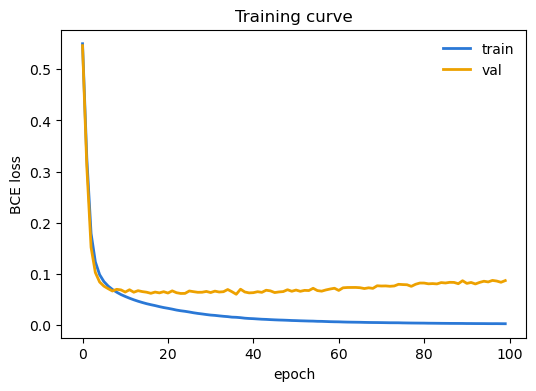

In [10]:
COLOR_TRAIN = "#2a78d6"  # categorical slot 1 (blue)
COLOR_VAL = "#eda100"    # categorical slot 3 (yellow)

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="train", color=COLOR_TRAIN, linewidth=2)
plt.plot(val_losses, label="val", color=COLOR_VAL, linewidth=2)
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.legend(frameon=False)
plt.title("Training curve")
plt.show()

In [11]:
test_loss, test_acc = evaluate(test_loader)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.3f}")

Test loss: 0.1003
Test accuracy: 0.977
